# Dataset Exploration

Use this notebook to check image counts and visually inspect sample food images before training.

In [1]:
import sys
print(sys.executable)

c:\Users\biyan\Documents\GitHub\.venv\Scripts\python.exe


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = Path('..') / 'dataset'
SPLITS = ['train', 'val', 'test']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

## Image Counts

In [3]:
counts = {}

for split in SPLITS:
    split_dir = DATASET_DIR / split
    counts[split] = {}
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        image_count = sum(
            1 for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
        counts[split][class_dir.name] = image_count

counts

{'train': {'burger': 30, 'pizza': 30, 'salad': 30},
 'val': {'burger': 10, 'pizza': 10, 'salad': 10},
 'test': {'burger': 10, 'pizza': 10, 'salad': 10}}

## Sample Images

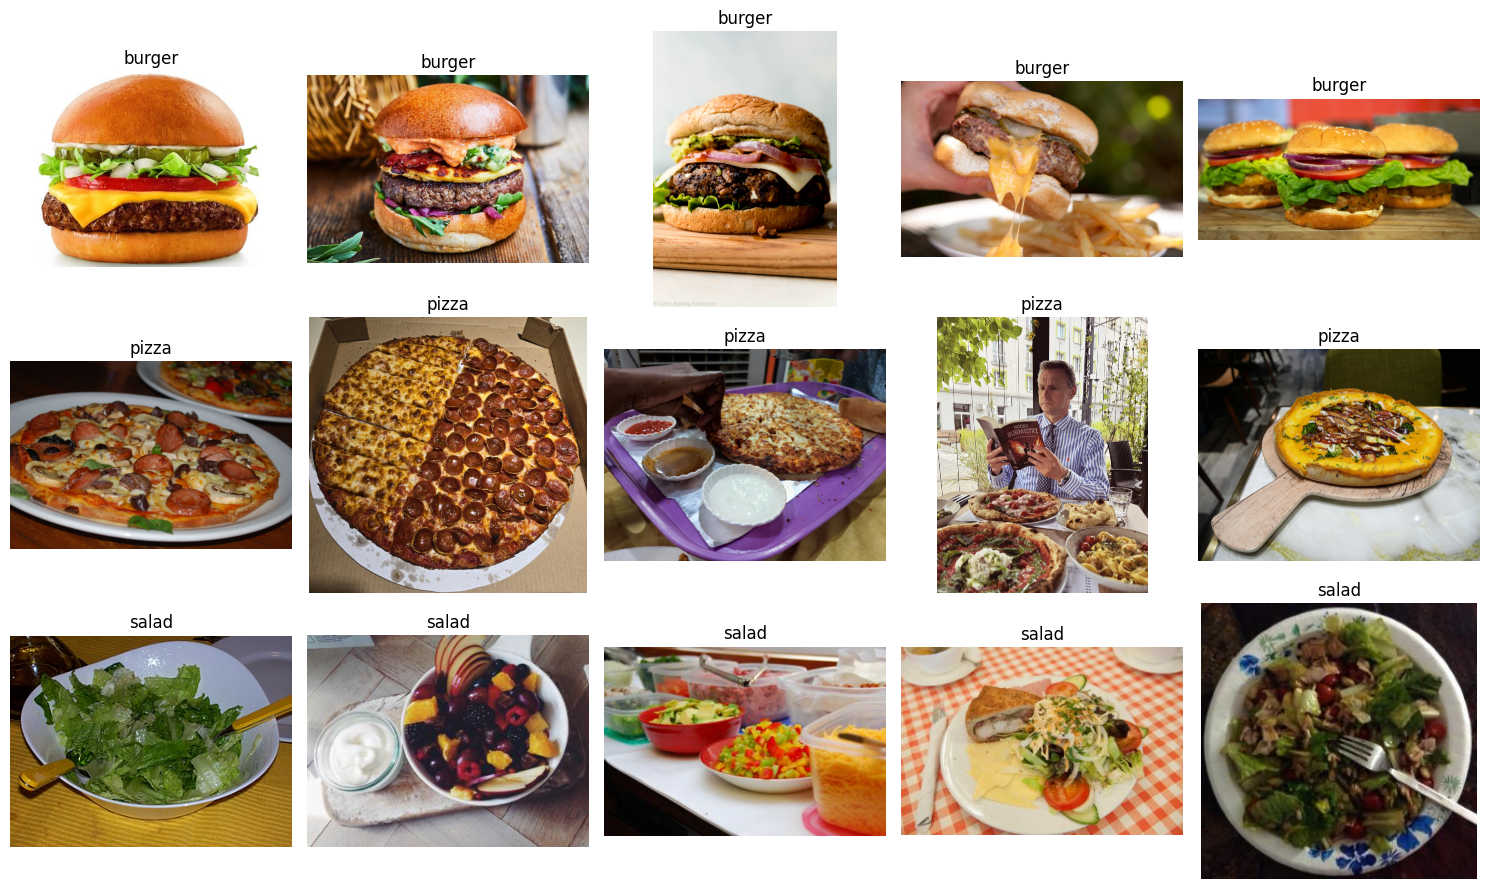

In [4]:
class_names = sorted(counts['train'].keys())
samples_per_class = 5

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(samples_per_class * 3, len(class_names) * 3),
)

for row, class_name in enumerate(class_names):
    image_paths = [
        path for path in (DATASET_DIR / 'train' / class_name).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ][:samples_per_class]

    for col in range(samples_per_class):
        ax = axes[row][col] if len(class_names) > 1 else axes[col]
        ax.axis('off')
        if col < len(image_paths):
            image = Image.open(image_paths[col]).convert('RGB')
            ax.imshow(image)
            ax.set_title(class_name)

plt.tight_layout()

## Image Sizes

In [5]:
sizes = []

for class_name in class_names:
    for image_path in (DATASET_DIR / 'train' / class_name).iterdir():
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            with Image.open(image_path) as image:
                sizes.append((class_name, image.width, image.height))

sizes[:10]

[('burger', 653, 452),
 ('burger', 1280, 853),
 ('burger', 1200, 1800),
 ('burger', 1280, 800),
 ('burger', 2400, 1200),
 ('burger', 1260, 709),
 ('burger', 1900, 1018),
 ('burger', 941, 705),
 ('burger', 1080, 1080),
 ('burger', 704, 396)]